
## AnalystLab Africa Internship
### Week 2 Data Cleaning and Exploratory Data Analysis (EDA)
### Netflix Movies and TV Show Dataset


#### Objective
The objective of this project is to explore and clean the Netflix Movies and TV Show dataset using Python. The analysis is aimed at improving data quality, understanding the data, and uncovering meaningful business insights through Exploratory Data Analysis (EDA).

In [1]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [8]:
# Loading the Netflix dataset
import pandas as pd 
netflix = pd.read_csv("Netflix/netflix_titles.csv")
# Shows the first 5 rows in the table
netflix.head
# Displaying column names 
netflix.columns
# Displaying information about the dataset 
netflix.info()
# Generating summary statistics for the dataset
netflix.describe(include="all")
# Checking for missing values 
netflix.isnull().sum()
# Filling missing values
## Fillling missing values in text columns 
netflix["director"] = netflix["director"].fillna("Unknown")
netflix["cast"] = netflix["cast"].fillna("Unknown")
netflix["country"] = netflix["country"].fillna("Unknown")
## Filling missing values with the most common value
netflix["rating"] = netflix["rating"].fillna(netflix["rating"].mode()[0])
netflix["duration"] = netflix["duration"].fillna(netflix["duration"].mode()[0])
## Remove rows with missing date_added values
netflix = netflix.dropna(subset=["date_added"]) 
# Checking for missing values again
netflix.isnull().sum()
# Checking for duplicate records 
netflix.duplicated().sum()
# Standardizing column nanes 
netflix.columns = netflix.columns.str.replace("_"," ").str.title()
# Displaying updated coulmn names
print(netflix.columns)
## Converting selected rows to proper columns
netflix["Director"] = netflix["Director"].str.strip().str.title()
netflix["Cast"] = netflix["Cast"].str.strip().str.title()
netflix["Country"] = netflix["Country"].str.strip().str.title()
netflix["Title"] = netflix["Title"].str.strip().str.title()
netflix["Type"] = netflix["Type"].str.strip().str.title()
## Converting date added to datetime format
netflix["Date Added"] = pd.to_datetime(netflix["Date Added"], format="mixed",errors="coerce")
# Displaying information about he dataset
netflix.info()
# Saving the cleaned dataset
netflix.to_csv("Netflix/cleaned_netflix.csv", index=False)
netflix.iloc[8411]


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
Index(['Show Id', 'Type', 'Title', 'Director', 'Cast', 'Country', 'Date Added',
       'Release Year', 'Rating', 'Duration', 'Listed In', 'Description'],
      dtype='str')
<class 'pandas.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column      

Show Id                                                     s8422
Type                                                      Tv Show
Title                                              The Messengers
Director                                                  Unknown
Cast            Shantel Vansanten, Diogo Morgado, Jd Pardo, Jo...
Country                                             United States
Date Added                                    2016-04-17 00:00:00
Release Year                                                 2015
Rating                                                      TV-14
Duration                                                 1 Season
Listed In            TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy
Description     A group of strangers who are killed by a myste...
Name: 8421, dtype: object

#### Summary of Data Cleaning 
* Missing values were handled using appropriate imputation and row removal technique.
* Duplicate records were not found in the dataset.
* Text fields were standardized for consistency.
* The Date Added column was converted to datetime format.
* The cleaned dataset was exported as a CSV file.

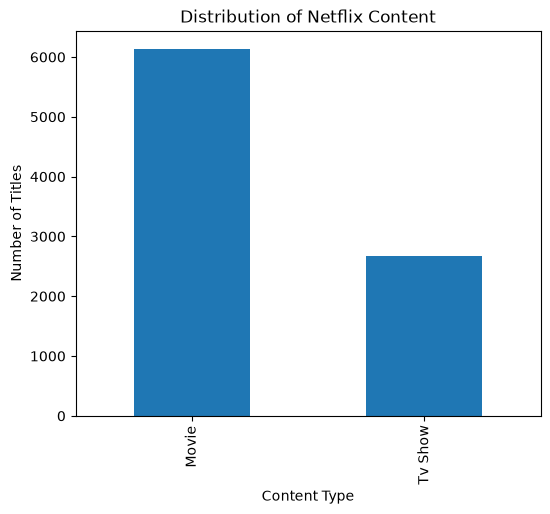

In [9]:
import matplotlib.pyplot as plt

# Exploratory Data Analytics(EDA)
## Number of Movies and TV Shows 
netflix["Type"].value_counts()
### Creating a bar chart for visualizaton
netflix["Type"].value_counts().plot(kind="bar", figsize=(6,5))

plt.title("Distribution of Netflix Content")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

#### Distribution of Movies and TV Shows
The analysis shows that movies make up a larger proportion of Netflix's content than TV shows. Suggesting that Netflix catalogue is more heavily focused on movies.

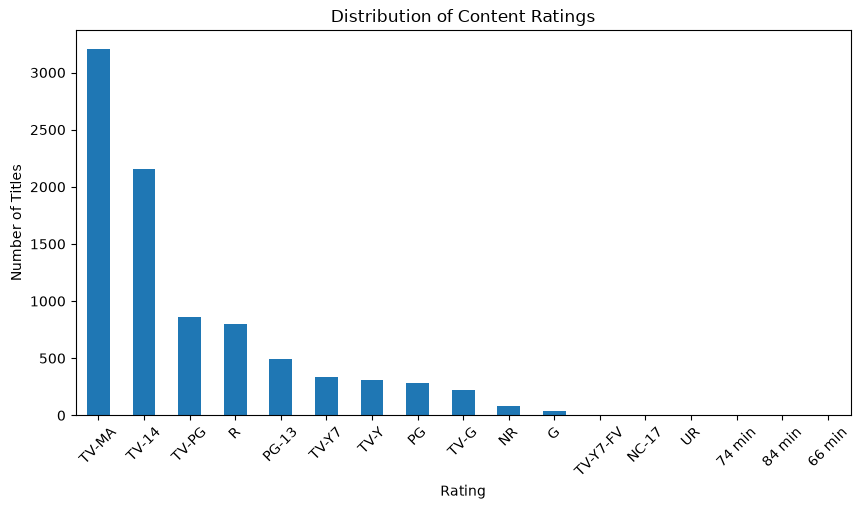

In [10]:
## Displaying Content ratings 
netflix["Rating"].value_counts()
### Creating a bar chart for content ratings 
netflix["Rating"].value_counts().plot(kind="bar", figsize=(10,5))

plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

#### Distribution of Content Rating
The TV-MA rating is the highest, indicating that a large portion of netflix content is intended for mature audiences. Other ratings are also presented showing diversification in audience.

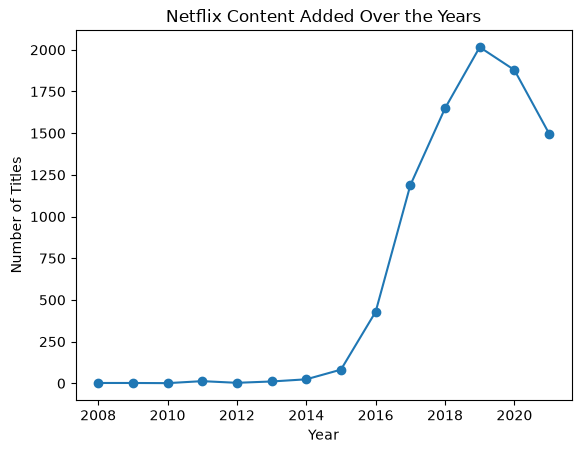

In [11]:
## Extracting the year from the Date Added column 
netflix["Year Added"] = netflix["Date Added"].dt.year
### Number of titles added each year
netflix["Year Added"].value_counts().sort_index().plot(kind="line", marker="o")

plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()


#### Content Added Over the Years
The number of titles added to Netflix increased steadily over the years, reaching its peak in 2019. This trend reflects the platforms rapid expansion of its content library.

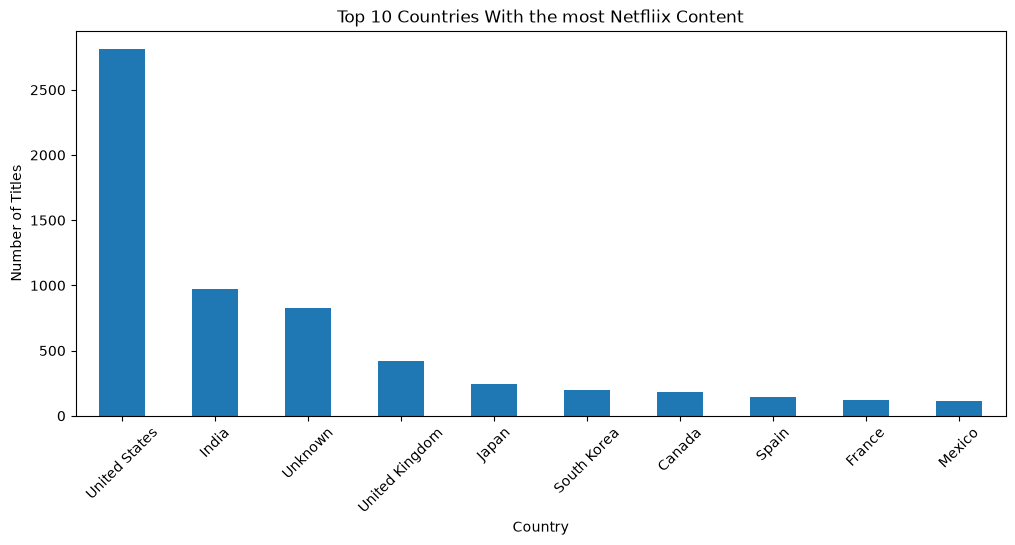

In [12]:
## Top 10 Countries by Number of Titles
netflix["Country"].value_counts().head(10).plot(kind="bar", figsize=(12,5))

plt.title("Top 10 Countries With the most Netfliix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

#### Top 10 Countries
The United States has the highrst number of titless in the data, followed by India and other countries with significantly smaller countributions. U.S is the dominant source of Netflix content.

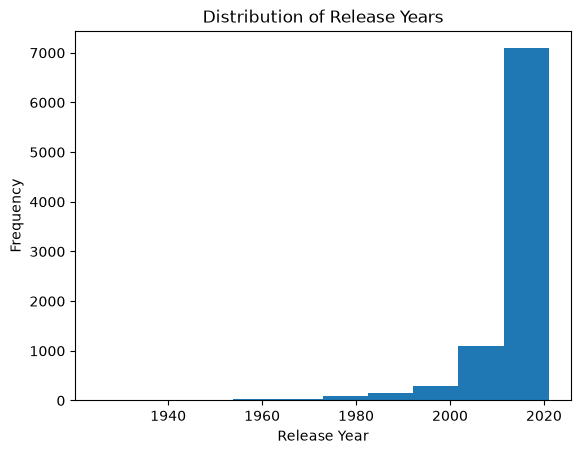

In [13]:
## Release Year Distribution
netflix["Release Year"].plot(kind="hist")

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()


#### Release Year Distribution
Most titles come from recent years while a few comes from decades back. This sugggests that Netflix focuses on offering recent content alongside a smaller collection of older titles.

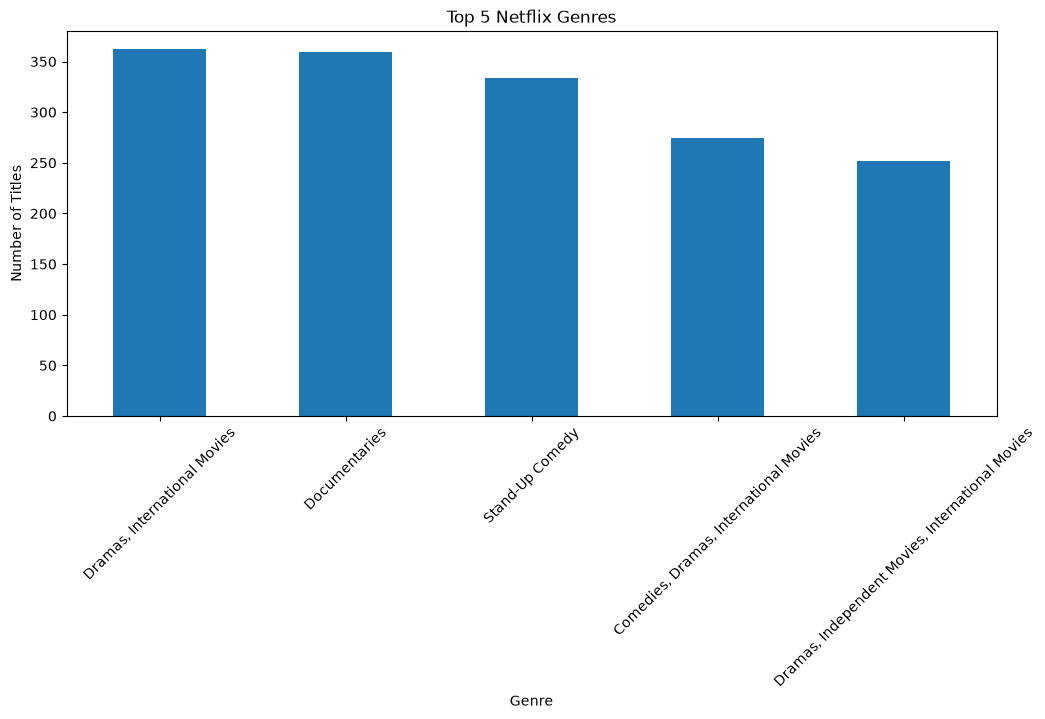

In [14]:
## Top 5 Genres 
netflix["Listed In"].value_counts().head(5).plot(kind="bar", figsize=(12,5))

plt.title("Top 5 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()


#### Top 5 Genre
Drama, Intternational Movies topped the chart as no 1 occuring much more than others, which shows with little or more diiference from the previous. This highlights the platforms effort to meet the viewing preferrences of its broad audience.


## Summary 
The Netflix dataset was successfully cleaned and explored using python. The analysis revealed that movies dominated the platforms catalogue, the United States is the leading content producer, mature-rated conent is most common, and Netflix has expanded its library significantly over time while maintaining a strong focus on recently released titles.